# Initial-shock variability: E3SM and CESM-SMYLE

Archive-backed companion to `1a_refactor_atm_leadtime_acc_skill_map.ipynb`.

**Configure → inventory and cache plan → monthly archive preparation and common-grid
calculation → cached diagnostics → case comparisons → individual initialization plots.**

This uses the same E3SM post-processing archive, CESM-SMYLE benchmark archive,
observation accessors and regridding utilities as `1a`. The calculation is separate:
no detrending, lead-drift removal, or ACC anomaly inputs. The scalar ratio is the
model ensemble-mean temporal standard deviation divided by observed standard deviation.


In [33]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / 'esp_lab').is_dir()), None)
if repo_root is not None:
    sys.path.insert(0, str(repo_root))
from importlib import reload
from esp_lab.diagnostics import initial_shock as initial_shock_diagnostic
initial_shock_diagnostic = reload(initial_shock_diagnostic)
plot_std_ratio = initial_shock_diagnostic.plot_std_ratio
plot_normalized_change = initial_shock_diagnostic.plot_normalized_change
from workflows.diagnostics import initial_shock_archive as initial_shock_archive_workflow
if initial_shock_archive_workflow.ARCHIVE_VERSION != 'initial_shock_archive_v2':
    initial_shock_archive_workflow = reload(initial_shock_archive_workflow)
plan_archive_run = initial_shock_archive_workflow.plan_archive_run
compute_archive_plan = initial_shock_archive_workflow.compute_archive_plan
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.resource_utils import ResourceTracker


## User setup and workflow configuration

Select a field and the E3SM cases here, as in `1a`. Input files are discovered through
the existing archive accessors; no manually prepared monthly filenames are needed.
`TREFHT` is the temperature diagnostic used in the NCL example. All conversion
factors below assume the same archive conventions as `1a`; PRECT is mm/day after conversion.

The original NCL index needs five annual samples (60 months). With the current
24-month archive, these defaults explicitly compute an **exploratory two-block
ratio**, using two consecutive 12-month means. May blocks are May–April; November
blocks are November–October. This is not the original five-year statistic.


In [34]:
VAR_CONFIG = {
    'TREFHT': dict(obs_product='ERA5', obs_variable='tas', units='degC',
                   model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
                   obs_scale=1., obs_offset=-273.15),
    'TS': dict(obs_product='ERA5', obs_variable='ts', units='degC',
               model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
               obs_scale=1., obs_offset=-273.15),
    'PRECT': dict(obs_product='GPCP_v2.3', obs_variable='PRECT', units='mm/day',
                  model_scale=86400000., model_offset=0., smyle_scale=86400000., smyle_offset=0.,
                  obs_scale=1., obs_offset=0.),
    'PSL': dict(obs_product='ERA5', obs_variable='psl', units='hPa',
                model_scale=.01, model_offset=0., smyle_scale=.01, smyle_offset=0.,
                obs_scale=.01, obs_offset=0.),
}
field = 'TREFHT'
variable = dict(VAR_CONFIG[field], field=field, model_variable=field, smyle_variable=field)

# Explicit color-bin boundaries for the normalized-change heatmaps.
HEATMAP_COLORBAR_LEVELS = {
    'signed_normalized_change': np.linspace(-2.0, 2.0, 11),
    'absolute_normalized_change': np.linspace(0.0, 2.0, 11),
}

E3SM_CASES = {
    'E3SM-FOSIRL': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL', cache_tag='JRA55_FOSIRL'),
    'E3SM-Reanalysis': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce', cache_tag='Reanalysis'),
    'E3SM-4DEnVarOcn': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn', cache_tag='4DEnVarOcn'),
}
WORKFLOW_SETTINGS = {
    'paths': {
        's2d_diag_root': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag',
        'figure_outdir': '/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock',
    },
    'run': {'years': [1980, 2011], 'init_months': [5, 11], 'nlead': 24, 'smoke_mode': False},
    'e3sm': {
        'data_dir': '/global/cfs/cdirs/e3sm/S2S2D/post_process',
        'nens': 10, 'grid': '180x360_aave', 'ts_split': '2yr', 'engine': 'netcdf4',
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 90, 'lon': 180},
    },
    'smyle': {
        'include': True, 'nens': 20,
        'benchmark_dir': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE',
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 96, 'lon': 144},
    },
    'obs': {
        'data_dir': '/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series',
        'chunks': {'time': 24, 'lat': 90, 'lon': 180},
    },
    'regrid': {'target_dlat': 1., 'target_dlon': 1., 'method': 'conservative', 'periodic': True},
    'metric': {'window_months': 24, 'block_months': 12, 'start_lead': 0,
               'min_samples': None, 'min_area_fraction': .9,
               'climatology_years': [1981, 2010]},
    'cache': {'mode': 'auto', 'force_compute': False},  # set force_compute=True to refresh valid caches
    'dask': {'enabled': True, 'workers': 8},
}
if WORKFLOW_SETTINGS['run']['smoke_mode']:
    E3SM_CASES = {'E3SM-FOSIRL': E3SM_CASES['E3SM-FOSIRL']}
    WORKFLOW_SETTINGS['run'].update(years=[1980, 1981], init_months=[11])
    WORKFLOW_SETTINGS['regrid'].update(target_dlat=5., target_dlon=5.)
    WORKFLOW_SETTINGS['dask']['workers'] = 2
    print('Archive-backed smoke mode: one E3SM case, CESM-SMYLE, two starts, one month.')
print('Field:', field, '| Years:', WORKFLOW_SETTINGS['run']['years'])
print('Metric:', WORKFLOW_SETTINGS['metric'])


Field: TREFHT | Years: [1980, 2011]
Metric: {'window_months': 24, 'block_months': 12, 'start_lead': 0, 'min_samples': None, 'min_area_fraction': 0.9, 'climatology_years': [1981, 2010]}


## Inventory and cache plan

Inventory all requested initializations before starting expensive processing.
All E3SM members are required. Missing initializations cause an error rather than
silently shortening a case's comparison period. This also checks CESM-SMYLE
**monthly** benchmark availability and identifies the observation source.

Identity includes source file inventories, settings and adapter code. Compatible
metric caches can be reused without remapping the data. `require` needs source
metadata and existing compatible caches. Rerun this cell after changing settings.


In [35]:
archive_plan = plan_archive_run(WORKFLOW_SETTINGS, E3SM_CASES, variable)
plan_table = pd.DataFrame([
    {'case': t['case'], 'init_month': t['month'], 'initializations': len(t['years']),
     'source_files': len(t['inventory']), 'action': 'prepare' if t['rebuild'] else 'reuse',
     'cache': t['path']}
    for t in archive_plan
])
display(plan_table)


,case,init_month,initializations,source_files,action,cache
0,E3SM-FOSIRL,5,32,321,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FO...
1,E3SM-Reanalysis,5,32,321,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalys...
2,E3SM-4DEnVarOcn,5,32,321,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarO...
3,CESM-SMYLE,5,32,2,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMY...
4,E3SM-FOSIRL,11,32,321,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FO...
5,E3SM-Reanalysis,11,32,321,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalys...
6,E3SM-4DEnVarOcn,11,32,321,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarO...
7,CESM-SMYLE,11,32,2,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMY...


## Dask resources

Start after the inventory succeeds. Rerunning this cell closes the previous cluster.
Run the cleanup cell when finished, including after an interrupted computation.


In [36]:
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(DaskConfig(
        cluster_type='local', workers=WORKFLOW_SETTINGS['dask']['workers']))
        if WORKFLOW_SETTINGS['dask']['enabled'] else (None, None),
)
if client is not None:
    display(client)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


Scheduler: tcp://127.0.0.1:41747
Connected workers: 4
Dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41747,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39081,Total threads: 1
Dashboard: http://127.0.0.1:38555/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:35791,


## Monthly preparation, common-grid calculation, and cache writing

For each missing case/month product, the module opens monthly archives, validates
represented verification months, converts units, regrids model and observation,
and computes the metric. Each source dataset is closed after the calculation.

To save space, the preparation and metric stages write **compact global block
indices, coverage and normalized changes**, not duplicate gridded monthly files. These live
under `<case>/initial_shock/metrics/atm/<field>/`, separate from ACC/RMSE outputs.
The normalized-change denominator uses unique observed first-block annual means
over `metric.climatology_years`: May-April for May starts and November-October
for November starts.


In [37]:
comparison_by_month = compute_archive_plan(archive_plan, WORKFLOW_SETTINGS, variable)
for month, comparison in comparison_by_month.items():
    print(f'Initialization month {month:02d}')
    display(comparison[['signed_normalized_change', 'absolute_normalized_change',
                        'excess_normalized_change', 'observation_climatology_std',
                        'std_ratio', 'paired_sample_count', 'valid_normalized_change']])


Reusing E3SM-FOSIRL init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TREFHT/init05_7c4afbf7e3e109ed353e.nc
Reusing E3SM-Reanalysis init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TREFHT/init05_8870053374ebca10e031.nc
Reusing E3SM-4DEnVarOcn init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TREFHT/init05_eb2eb8b973f13ffaedd1.nc
Reusing CESM-SMYLE init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/initial_shock/metrics/atm/TREFHT/init05_77ab0584e6b2bfb1e086.nc
Reusing E3SM-FOSIRL init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TREFHT/init11_03aad61764b313b3b0a7.nc
Reusing E3SM-Reanalysis init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TREFHT/init11_1d1f750512f9418fa269.nc
Reusing E3SM-4DEnVarOcn init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TREFHT/init11_74760afb9a4

<xarray.Dataset> Size: 6kB
Dimensions:                      (case: 4, Y: 32)
Coordinates:
  * case                         (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SM...
  * Y                            (Y) int64 256B 1980 1981 1982 ... 2010 2011
    height                       float64 8B 2.0
Data variables:
    signed_normalized_change     (case, Y) float64 1kB -1.417 -1.447 ... 0.3741
    absolute_normalized_change   (case, Y) float64 1kB 1.417 1.447 ... 0.3741
    excess_normalized_change     (case, Y) float64 1kB -0.8442 ... -0.2257
    observation_climatology_std  (case) float64 32B 0.1814 0.1814 0.1814 0.1814
    std_ratio                    (case, Y) float64 1kB 2.473 6.578 ... 0.6237
    paired_sample_count          (case, Y) int64 1kB 2 2 2 2 2 2 ... 2 2 2 2 2 2
    valid_normalized_change      (case, Y) int8 128B 1 1 1 1 1 1 ... 1 1 1 1 1 1
Attributes: (12/15)
    diagnostic_version:             initial_shock_std_v2
    block_months:                   12
    window_months:                  24
    start_lead_position:            0
    min_samples:                    2
    ddof:                           1
    ...                             ...
    averaging_order:                ensemble mean; unweighted monthly blocks;...
    interpretation:                 Primary metric is signed lead-year change...
    normalized_change_climatology:  1981-2010
    normalized_change_denominator:  sample std of observed first-block means ...
    field:                          TREFHT
    init_month:                     5

Initialization month 11


<xarray.Dataset> Size: 6kB
Dimensions:                      (case: 4, Y: 32)
Coordinates:
  * case                         (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SM...
  * Y                            (Y) int64 256B 1980 1981 1982 ... 2010 2011
    height                       float64 8B 2.0
Data variables:
    signed_normalized_change     (case, Y) float64 1kB -1.136 -0.9505 ... 0.104
    absolute_normalized_change   (case, Y) float64 1kB 1.136 0.9505 ... 0.104
    excess_normalized_change     (case, Y) float64 1kB -0.2309 ... -0.1208
    observation_climatology_std  (case) float64 32B 0.1893 0.1893 0.1893 0.1893
    std_ratio                    (case, Y) float64 1kB 1.255 0.9515 ... 0.4627
    paired_sample_count          (case, Y) int64 1kB 2 2 2 2 2 2 ... 2 2 2 2 2 2
    valid_normalized_change      (case, Y) int8 128B 1 1 1 1 1 1 ... 1 1 1 1 1 1
Attributes: (12/15)
    diagnostic_version:             initial_shock_std_v2
    block_months:                   12
    window_months:                  24
    start_lead_position:            0
    min_samples:                    2
    ddof:                           1
    ...                             ...
    averaging_order:                ensemble mean; unweighted monthly blocks;...
    interpretation:                 Primary metric is signed lead-year change...
    normalized_change_climatology:  1981-2010
    normalized_change_denominator:  sample std of observed first-block means ...
    field:                          TREFHT
    init_month:                     11

## Coverage, normalized-change tables and heatmaps

The primary signed metric is `(M2-M1) / sigma_obs_clim`; positive values indicate
an increase from lead year 1 to lead year 2 and negative values indicate a decrease.
The secondary absolute metric shows adjustment magnitude. May and November share
a figure and color scale for each metric. The legacy two-point std ratio remains in
the tables for continuity but is not the primary diagnostic.


,case,Y,signed_normalized_change,absolute_normalized_change,excess_normalized_change,model_lead_year_change,observation_lead_year_change,observation_climatology_std,observation_climatology_sample_count,std_ratio,paired_sample_count,valid_normalized_change,height
0,E3SM-FOSIRL,1980,-1.417465,1.417465,-0.844203,-0.257061,-0.103962,0.181352,30,2.472632,2,1,2.0
1,E3SM-FOSIRL,1981,-1.447033,1.447033,-1.667010,-0.262423,0.039893,0.181352,30,6.578095,2,1,2.0
2,E3SM-FOSIRL,1982,-1.121311,1.121311,-1.073606,-0.203352,-0.008651,0.181352,30,23.505040,2,1,2.0
3,E3SM-FOSIRL,1983,-2.035942,2.035942,-1.190879,-0.369223,-0.153254,0.181352,30,2.409218,2,1,2.0
4,E3SM-FOSIRL,1984,-0.987197,0.987197,-1.176473,-0.179030,0.034326,0.181352,30,5.215635,2,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,CESM-SMYLE,2007,0.225725,0.225725,0.045039,0.040936,0.032768,0.181352,30,1.249268,2,1,2.0
124,CESM-SMYLE,2008,0.556209,0.556209,-0.390848,0.100870,0.171751,0.181352,30,0.587303,2,1,2.0
125,CESM-SMYLE,2009,0.597662,0.597662,1.146247,0.108387,-0.099487,0.181352,30,1.089463,2,1,2.0
126,CESM-SMYLE,2010,-0.177517,0.177517,0.083900,-0.032193,-0.047409,0.181352,30,0.679058,2,1,2.0


<xarray.Dataset> Size: 2kB
Dimensions:                    (case: 4, Y: 32)
Coordinates:
  * case                       (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SMYLE'
  * Y                          (Y) int64 256B 1980 1981 1982 ... 2009 2010 2011
    height                     float64 8B 2.0
Data variables:
    model_area_fraction        (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    observation_area_fraction  (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
Attributes: (12/15)
    diagnostic_version:             initial_shock_std_v2
    block_months:                   12
    window_months:                  24
    start_lead_position:            0
    min_samples:                    2
    ddof:                           1
    ...                             ...
    averaging_order:                ensemble mean; unweighted monthly blocks;...
    interpretation:                 Primary metric is signed lead-year change...
    normalized_change_climatology:  1981-2010
    normalized_change_denominator:  sample std of observed first-block means ...
    field:                          TREFHT
    init_month:                     5

,case,Y,signed_normalized_change,absolute_normalized_change,excess_normalized_change,model_lead_year_change,observation_lead_year_change,observation_climatology_std,observation_climatology_sample_count,std_ratio,paired_sample_count,valid_normalized_change,height
0,E3SM-FOSIRL,1980,-1.135889,1.135889,-0.230867,-0.214971,-0.171278,0.189253,30,1.255096,2,1,2.0
1,E3SM-FOSIRL,1981,-0.950453,0.950453,-1.949309,-0.179876,0.189037,0.189253,30,0.951541,2,1,2.0
2,E3SM-FOSIRL,1982,-1.718516,1.718516,-0.794917,-0.325235,-0.174794,0.189253,30,1.860674,2,1,2.0
3,E3SM-FOSIRL,1983,-1.221211,1.221211,-0.746108,-0.231118,-0.089915,0.189253,30,2.570415,2,1,2.0
4,E3SM-FOSIRL,1984,-0.704340,0.704340,-1.140542,-0.133299,0.082553,0.189253,30,1.614711,2,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,CESM-SMYLE,2007,-0.240732,0.240732,-0.901900,-0.045559,0.125128,0.189253,30,0.364101,2,1,2.0
124,CESM-SMYLE,2008,-0.124300,0.124300,-0.796686,-0.023524,0.127251,0.189253,30,0.184865,2,1,2.0
125,CESM-SMYLE,2009,-0.830893,0.830893,-0.076012,-0.157249,-0.142864,0.189253,30,1.100694,2,1,2.0
126,CESM-SMYLE,2010,-0.180300,0.180300,-0.247324,-0.034122,0.012685,0.189253,30,2.690070,2,1,2.0


<xarray.Dataset> Size: 2kB
Dimensions:                    (case: 4, Y: 32)
Coordinates:
  * case                       (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SMYLE'
  * Y                          (Y) int64 256B 1980 1981 1982 ... 2009 2010 2011
    height                     float64 8B 2.0
Data variables:
    model_area_fraction        (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    observation_area_fraction  (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
Attributes: (12/15)
    diagnostic_version:             initial_shock_std_v2
    block_months:                   12
    window_months:                  24
    start_lead_position:            0
    min_samples:                    2
    ddof:                           1
    ...                             ...
    averaging_order:                ensemble mean; unweighted monthly blocks;...
    interpretation:                 Primary metric is signed lead-year change...
    normalized_change_climatology:  1981-2010
    normalized_change_denominator:  sample std of observed first-block means ...
    field:                          TREFHT
    init_month:                     11

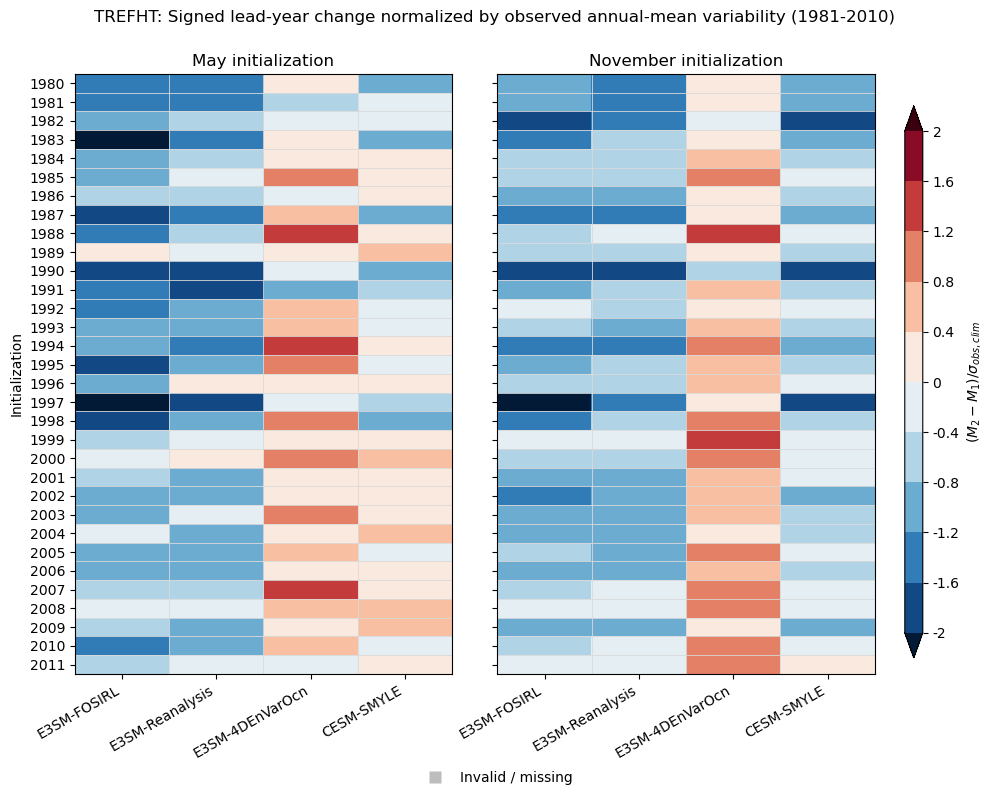

Saved normalized-change comparison: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock/TREFHT_init05-init11_signed_normalized_change.png


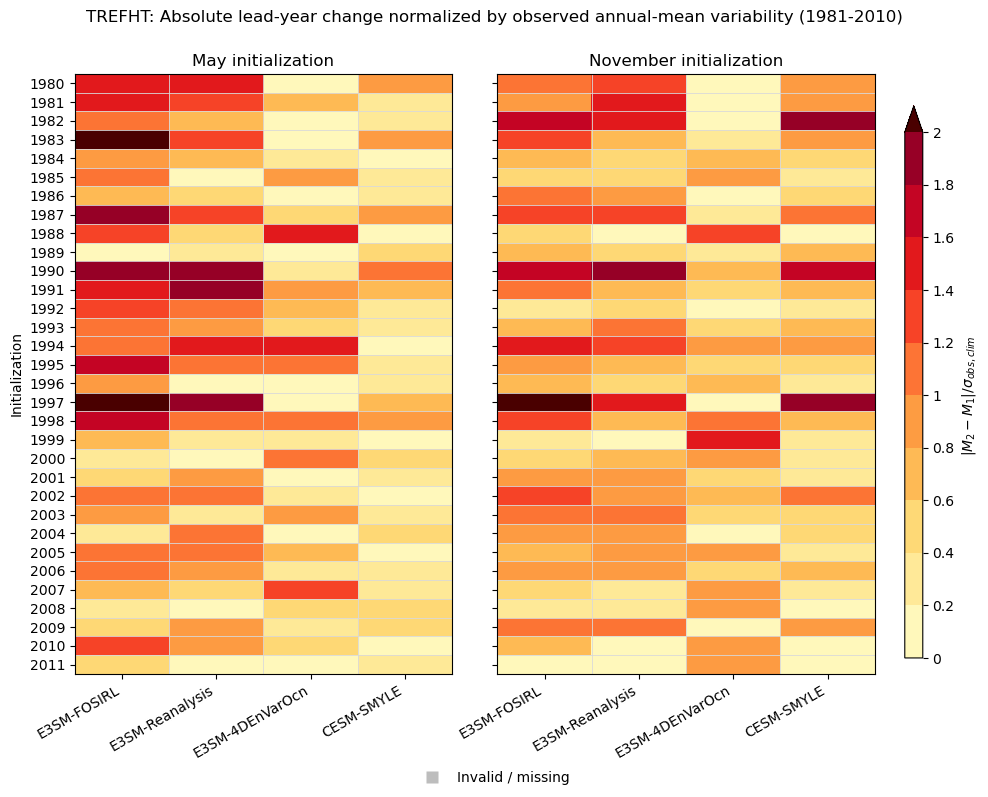

Saved normalized-change comparison: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock/TREFHT_init05-init11_absolute_normalized_change.png


In [38]:
FIGURE_ROOT = Path(WORKFLOW_SETTINGS['paths']['figure_outdir'])
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
import hashlib

for month, comparison in comparison_by_month.items():
    # Hash suffix prevents different case selections/settings from overwriting tables.
    identities = [t['digest'] for t in archive_plan if t['month'] == month]
    run_id = hashlib.sha256(''.join(identities).encode()).hexdigest()[:12]
    prefix = f'{field}_init{month:02d}_{run_id}'
    summary = comparison[['signed_normalized_change', 'absolute_normalized_change',
                          'excess_normalized_change', 'model_lead_year_change',
                          'observation_lead_year_change', 'observation_climatology_std',
                          'observation_climatology_sample_count', 'std_ratio',
                          'paired_sample_count', 'valid_normalized_change']].to_dataframe().reset_index()
    display(summary)
    display(comparison[['model_area_fraction', 'observation_area_fraction']].min('block'))
    summary.to_csv(FIGURE_ROOT / f'{prefix}_summary.csv', index=False)

plot_months = list(comparison_by_month)
max_years = max(comparison_by_month[month].sizes['Y'] for month in plot_months)
month_names = {5: 'May', 11: 'November'}
month_token = '-'.join(f'init{month:02d}' for month in plot_months)
change_plot_specs = [
    (
        'signed_normalized_change', 'signed_normalized_change', 'both',
        r'$(M_2-M_1) / \sigma_{obs,clim}$',
        'Signed lead-year change',
    ),
    (
        'absolute_normalized_change', 'absolute_normalized_change', 'max',
        r'$|M_2-M_1| / \sigma_{obs,clim}$',
        'Absolute lead-year change',
    ),
]

for metric_name, filename_metric, colorbar_extend, colorbar_label, figure_title in change_plot_specs:
    fig, axes = plt.subplots(
        1, len(plot_months),
        figsize=(max(8, 5 * len(plot_months)), max(5, max_years * .25)),
        sharey=True, squeeze=False,
    )
    for col, month in enumerate(plot_months):
        ax = axes[0, col]
        plot_normalized_change(
            comparison_by_month[month], variable=metric_name,
            levels=HEATMAP_COLORBAR_LEVELS[metric_name], ax=ax,
            add_colorbar=False, add_invalid_legend=False,
            title=f"{month_names.get(month, f'Month {month:02d}')} initialization",
        )
        if col:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)

    mesh = axes[0, 0].images[0]
    bounds = np.asarray(mesh.norm.boundaries)
    fig.subplots_adjust(left=.08, right=.88, bottom=.15, top=.90, wspace=.12)
    colorbar_ax = fig.add_axes([.91, .17, .018, .69])
    colorbar = fig.colorbar(
        mesh, cax=colorbar_ax, ticks=bounds, extend=colorbar_extend,
    )
    colorbar.set_label(colorbar_label)
    colorbar.ax.set_yticklabels([f'{value:g}' for value in bounds])
    invalid_handle = plt.Line2D(
        [], [], marker='s', linestyle='none', markersize=8,
        markerfacecolor=mesh.cmap.get_bad(), markeredgecolor='none',
        label='Invalid / missing',
    )
    fig.legend(handles=[invalid_handle], loc='lower center', frameon=False)
    climatology_label = comparison_by_month[plot_months[0]].attrs.get(
        'normalized_change_climatology', 'available years'
    )
    fig.suptitle(
        f'{field}: {figure_title} normalized by observed annual-mean variability '
        f'({climatology_label})'
    )
    figure_path = FIGURE_ROOT / f'{field}_{month_token}_{filename_metric}.png'
    fig.savefig(figure_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved normalized-change comparison:', figure_path)


## Compare normalized model and observed lead-year changes

Each point is an initialization year. The 1:1 line denotes equal model and observed
lead-year change; displacement from it is the excess normalized-change diagnostic.


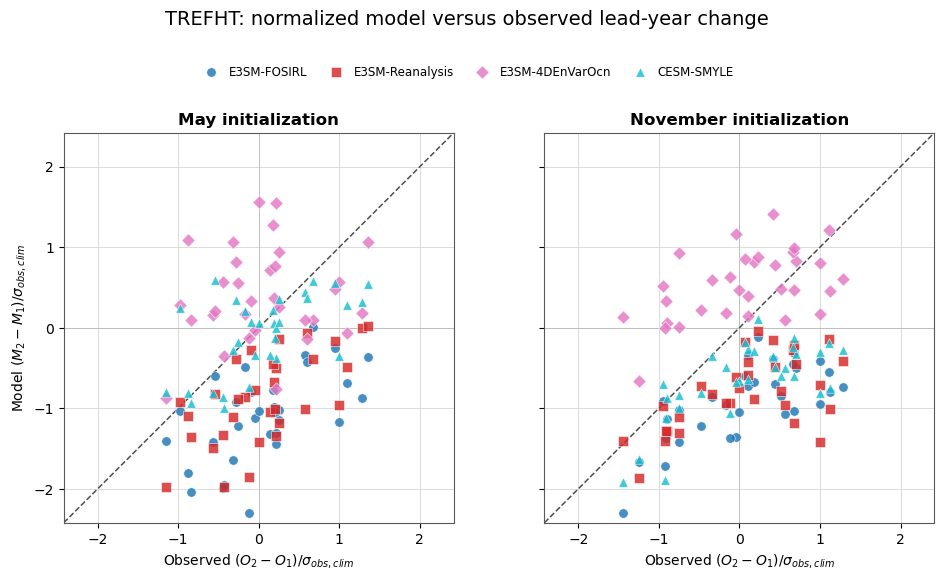

Saved normalized-change scatter: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock/TREFHT_init05-init11_normalized_change_scatter.png


In [39]:
plot_months = list(comparison_by_month)
case_names = list(dict.fromkeys(
    str(case) for month in plot_months for case in comparison_by_month[month].case.values
))
case_colors = dict(zip(
    case_names, plt.colormaps['tab10'](np.linspace(0, 1, max(2, len(case_names))))
))
default_case_markers = {
    'E3SM-FOSIRL': 'o',
    'E3SM-Reanalysis': 's',
    'E3SM-4DEnVarOcn': 'D',
    'CESM-SMYLE': '^',
    'NMME': 'X',
}
fallback_markers = ('o', 's', 'D', '^', 'v', 'P', 'X', '*')
case_markers = {
    case: default_case_markers.get(case, fallback_markers[index % len(fallback_markers)])
    for index, case in enumerate(case_names)
}
finite_changes = []
for comparison in comparison_by_month.values():
    observed_normalized = (
        comparison.observation_lead_year_change
        / comparison.observation_climatology_std
    )
    for values in (observed_normalized.values, comparison.signed_normalized_change.values):
        values = np.asarray(values, dtype=float)
        finite_changes.extend(values[np.isfinite(values)].tolist())
if not finite_changes:
    raise ValueError('No finite normalized lead-year changes to plot.')
axis_limit = max(1.0, max(abs(value) for value in finite_changes) * 1.05)

fig, axes = plt.subplots(
    1, len(plot_months), figsize=(5 * len(plot_months), 6),
    sharex=True, sharey=True, squeeze=False,
)
month_names = {5: 'May', 11: 'November'}
for col, month in enumerate(plot_months):
    ax = axes[0, col]
    comparison = comparison_by_month[month]
    for case in case_names:
        if case not in set(map(str, comparison.case.values)):
            continue
        data = comparison.sel(case=case)
        observed = np.asarray(
            (data.observation_lead_year_change / data.observation_climatology_std).values,
            dtype=float,
        )
        modeled = np.asarray(data.signed_normalized_change.values, dtype=float)
        valid = np.isfinite(observed) & np.isfinite(modeled)
        ax.scatter(
            observed[valid], modeled[valid], s=46, alpha=.82,
            marker=case_markers[case], color=case_colors[case],
            edgecolor='white', linewidth=.45, label=case, zorder=3,
        )
    ax.plot(
        [-axis_limit, axis_limit], [-axis_limit, axis_limit],
        color='.30', linestyle='--',
        linewidth=1.1, zorder=2,
    )
    ax.axhline(0, color='.75', linewidth=.7, zorder=1)
    ax.axvline(0, color='.75', linewidth=.7, zorder=1)
    ax.set(
        xlim=(-axis_limit, axis_limit), ylim=(-axis_limit, axis_limit),
        xlabel=r'Observed $(O_2-O_1) / \sigma_{obs,clim}$',
        title=f"{month_names.get(month, f'Month {month:02d}')} initialization",
    )
    ax.title.set_fontweight('semibold')
    ax.set_aspect('equal', adjustable='box')
    ax.set_axisbelow(True)
    ax.grid(color='.86', linewidth=.7)
    for spine in ax.spines.values():
        spine.set_color('.35')
        spine.set_linewidth(.8)
axes[0, 0].set_ylabel(r'Model $(M_2-M_1) / \sigma_{obs,clim}$')
fig.suptitle(f'{field}: normalized model versus observed lead-year change', y=.975, fontsize=14)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='upper center', bbox_to_anchor=(.5, .90),
    ncol=max(1, len(case_names)), fontsize=8.5, frameon=False,
    handletextpad=.5, columnspacing=1.4,
)
fig.subplots_adjust(left=.085, right=.98, bottom=.12, top=.77, wspace=.16)

month_token = '-'.join(f'init{month:02d}' for month in plot_months)
scatter_path = FIGURE_ROOT / f'{field}_{month_token}_normalized_change_scatter.png'
fig.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved normalized-change scatter:', scatter_path)


## Cleanup

Cached metrics remain available for plotting. Source files are closed inside the
workflow; this cell releases the optional distributed cluster.

See [methodology](../docs/initial_shock_std_index.md) for interpretation and
[the NCL reference](../temp/Compute_Std_Index_Initial_Shock_share.ncl).


In [40]:
close_notebook_resources(globals())
print('Closed notebook Dask resources.')


Closed notebook Dask resources.
